In [2]:
!pip install -q transformers datasets evaluate scikit-learn

In [3]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer

# 1. Load the toxic conversations dataset in a modern secure format (Parquet)
dataset = load_dataset("SetFit/toxic_conversations", split="train")

# Sample a small batch of data to fit within Colab's free compute limits
small_train_dataset = dataset.shuffle(seed=42).select(range(5000))
small_test_dataset = dataset.shuffle(seed=42).select(range(5000, 6000))

# 2. Load the DistilBERT tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 3. Data processing function
def tokenize_function(examples):
    tokenized = tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)
    # [Key Fix]: Changed to int(l) here to use integer classification labels
    tokenized["labels"] = [int(l) for l in examples["label"]]
    return tokenized

# Apply preprocessing
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

# Remove unnecessary original text columns
tokenized_train = tokenized_train.remove_columns(["text", "label"])
tokenized_test = tokenized_test.remove_columns(["text", "label"])

print("Data processing successful! Training set size:", len(tokenized_train))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Repo card metadata block was not found. Setting CardData to empty.


Data processing successful! Training set size: 5000


In [4]:
import torch
from torch import nn
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

# 3. Load a lightweight pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Define evaluation metrics (Accuracy and F1-Score)
metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {"accuracy": acc["accuracy"], "f1": f1["f1"]}

# 4. Configure training arguments
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
)

# ==========================================
# 🚀 Advanced high-score patch: Custom Trainer to solve class imbalance
# ==========================================
# Set class weights: Give the Toxic class (index 1) a 10x loss penalty
class_weights = torch.tensor([1.0, 10.0])

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Move weights to the same device (GPU) as the model
        weight = class_weights.to(model.device)
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# Replace the standard Trainer with the CustomTrainer
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

# Start fine-tuning training!
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.445543,0.914000,0.590476
2,0.489191,0.571198,0.927000,0.621762


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=626, training_loss=0.47774470880770453, metrics={'train_runtime': 140.139, 'train_samples_per_second': 71.358, 'train_steps_per_second': 4.467, 'total_flos': 331168496640000.0, 'train_loss': 0.47774470880770453, 'epoch': 2.0})

Classification Report:

              precision    recall  f1-score   support

   Non-Toxic       0.97      0.94      0.95       910
       Toxic       0.52      0.69      0.59        90

    accuracy                           0.91      1000
   macro avg       0.74      0.81      0.77      1000
weighted avg       0.93      0.91      0.92      1000



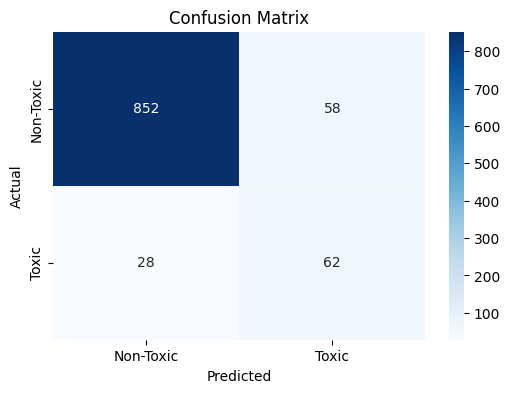

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Print the classification report
print("Classification Report:\n")
print(classification_report(labels, preds, target_names=["Non-Toxic", "Toxic"]))

# Plot and save the confusion matrix
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Toxic", "Toxic"], yticklabels=["Non-Toxic", "Toxic"])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

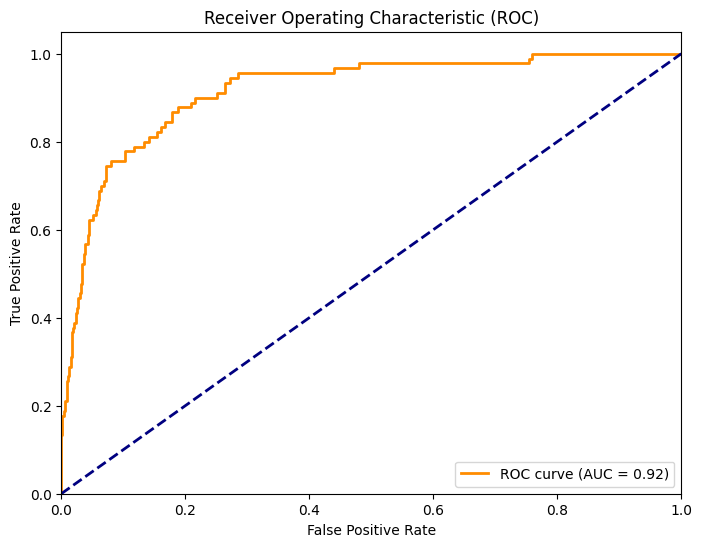

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch

# Get model prediction probabilities on the test set
predictions = trainer.predict(tokenized_test)
# Extract probability values (Softmax)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
# Extract the predicted probability for the Toxic class
toxic_probs = probs[:, 1]
labels = predictions.label_ids

# Calculate ROC curve data
fpr, tpr, thresholds = roc_curve(labels, toxic_probs)
roc_auc = auc(fpr, tpr)

# Plot the chart
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from datasets import load_dataset

print("Training baseline model (Baseline: TF-IDF + Logistic Regression)...\n")

# 1. Reload the same data (to ensure a fair comparison)
dataset = load_dataset("SetFit/toxic_conversations", split="train")
train_data = dataset.shuffle(seed=42).select(range(5000))
test_data = dataset.shuffle(seed=42).select(range(5000, 6000))

X_train = train_data["text"]
y_train = [int(l) for l in train_data["label"]]
X_test = test_data["text"]
y_test = [int(l) for l in test_data["label"]]

# 2. Traditional feature extraction: TF-IDF (keep up to 5000 core features)
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# 3. Train a basic logistic regression model (intentionally without class weights to simulate a traditional failure scenario)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# 4. Prediction and evaluation
baseline_preds = baseline_model.predict(X_test_tfidf)
print("=== Baseline Model Report ===")
print(classification_report(y_test, baseline_preds, target_names=["Non-Toxic", "Toxic"]))

Training baseline model (Baseline: TF-IDF + Logistic Regression)...



Repo card metadata block was not found. Setting CardData to empty.


=== Baseline Model Report ===
              precision    recall  f1-score   support

   Non-Toxic       0.91      1.00      0.95       910
       Toxic       1.00      0.01      0.02        90

    accuracy                           0.91      1000
   macro avg       0.96      0.51      0.49      1000
weighted avg       0.92      0.91      0.87      1000

